# 03 — Evaluación del Vision Transformer + Clasificación de Fotos Propias

**Proyecto:** Detección de Rostros Sintéticos Generados por StyleGAN3 mediante Vision Transformers
**Curso:** Computación Paralela y Distribuida | LEAD University
**Plataforma:** Kabré (nukwa-l40s, NVIDIA L40S)

Este notebook carga el modelo ViT-B/16 entrenado por `train_vit.py` (trabajo SBATCH) y:
1. Evalúa el modelo sobre el conjunto de test (accuracy, precision, recall, F1, AUC-ROC)
2. Genera matriz de confusión y curva ROC
3. Grafica las curvas de entrenamiento (loss/accuracy por época)
4. Visualiza mapas de atención del token `[CLS]` para interpretabilidad
5. Permite clasificar una foto propia (tuya o de cualquier persona)
6. Exporta un resumen de resultados para el dashboard (Etapa 6 del proyecto)


In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision.models import vit_b_16, ViT_B_16_Weights
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# ── Rutas del proyecto ────────────────────────────────────────────────────
PROJECT_ROOT = Path("/data/ulead-04/proyecto_paralela")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SRC_DIR = PROJECT_ROOT / "src"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC_DIR))
from preprocessing_worker import ChunkedNpyDataset, IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA L40S


## 1. Cargar el modelo entrenado

In [2]:
def build_model():
    weights = ViT_B_16_Weights.IMAGENET1K_V1
    model = vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, 2)
    return model

model = build_model().to(device)

ckpt_path = CHECKPOINTS_DIR / "vit_best.pt"
assert ckpt_path.exists(), f"No se encontró {ckpt_path} — ¿ya terminó el entrenamiento?"

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"✅ Modelo cargado desde {ckpt_path.name}")
print(f"   Época: {checkpoint['epoch'] + 1}")
print(f"   Mejor AUC-ROC (val): {checkpoint['best_auc']:.4f}")


/tmp/ipykernel_2954933/2677437773.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


✅ Modelo cargado desde vit_best.pt
   Época: 11
   Mejor AUC-ROC (val): 0.9520


## 2. Evaluación sobre el conjunto de Test

In [3]:
from torch.utils.data import DataLoader

test_ds = ChunkedNpyDataset(PROCESSED_DIR / "test")
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

print(f"Test set: {len(test_ds):,} imágenes")

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

test_metrics = {
    "accuracy":  accuracy_score(all_labels, all_preds),
    "precision": precision_score(all_labels, all_preds),
    "recall":    recall_score(all_labels, all_preds),
    "f1":        f1_score(all_labels, all_preds),
    "auc_roc":   roc_auc_score(all_labels, all_probs),
}

print("\n=== Métricas en Test ===")
for k, v in test_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

print("\n" + classification_report(all_labels, all_preds, target_names=["Fake", "Real"]))


Test set: 2,000 imágenes

=== Métricas en Test ===
  accuracy  : 0.8700
  precision : 0.8376
  recall    : 0.9180
  f1        : 0.8760
  auc_roc   : 0.9438

              precision    recall  f1-score   support

        Fake       0.91      0.82      0.86      1000
        Real       0.84      0.92      0.88      1000

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



## 3. Matriz de Confusión y Curva ROC

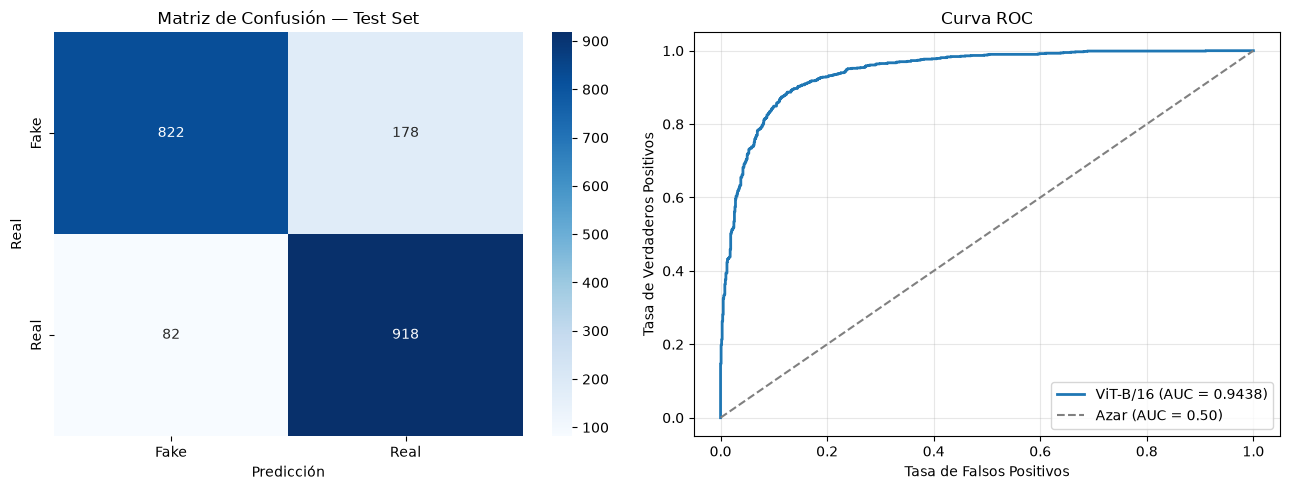

Guardado: /data/ulead-04/proyecto_paralela/figures/confusion_matrix_roc.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
axes[0].set_title("Matriz de Confusión — Test Set")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# Curva ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, color="#1f77b4", linewidth=2,
             label=f"ViT-B/16 (AUC = {test_metrics['auc_roc']:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Azar (AUC = 0.50)")
axes[1].set_xlabel("Tasa de Falsos Positivos")
axes[1].set_ylabel("Tasa de Verdaderos Positivos")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {FIGURES_DIR / 'confusion_matrix_roc.png'}")


## 4. Curvas de Entrenamiento

    epoch  train_loss  train_accuracy  train_precision  train_recall  \
0       1    0.659978        0.629313         0.641538      0.586125   
1       2    0.385047        0.824438         0.829671      0.816500   
2       3    0.203108        0.920750         0.924036      0.916875   
3       4    0.150634        0.941750         0.941088      0.942500   
4       5    0.118464        0.954187         0.955611      0.952625   
5       6    0.084695        0.966875         0.966409      0.967375   
6       7    0.081220        0.969187         0.968777      0.969625   
7       8    0.067505        0.975750         0.976465      0.975000   
8       9    0.067847        0.975500         0.975144      0.975875   
9      10    0.052003        0.980000         0.980480      0.979500   
10     11    0.066167        0.975688         0.975034      0.976375   
11     12    0.050246        0.980313         0.980012      0.980625   
12     13    0.050741        0.981875         0.980553      0.98

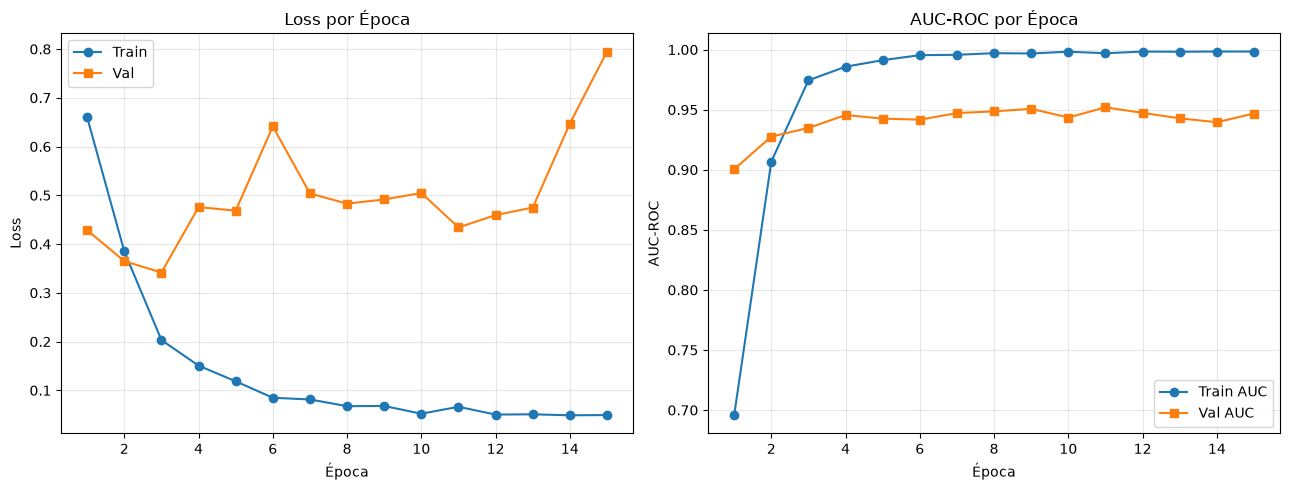


Throughput promedio (train): 565.1 img/s
Tiempo total de entrenamiento: 452.2 s


In [5]:
log_path = RESULTS_DIR / "training_log.csv"
df_log = pd.read_csv(log_path)
print(df_log)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_log["epoch"], df_log["train_loss"], marker="o", label="Train", color="#1f77b4")
axes[0].plot(df_log["epoch"], df_log["val_loss"], marker="s", label="Val", color="#ff7f0e")
axes[0].set_title("Loss por Época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_log["epoch"], df_log["train_auc_roc"], marker="o", label="Train AUC", color="#1f77b4")
axes[1].plot(df_log["epoch"], df_log["val_auc_roc"], marker="s", label="Val AUC", color="#ff7f0e")
axes[1].set_title("AUC-ROC por Época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("AUC-ROC")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Throughput reportado durante el entrenamiento (para el análisis de rendimiento del curso)
print(f"\nThroughput promedio (train): {df_log['train_throughput_img_s'].mean():.1f} img/s")
print(f"Tiempo total de entrenamiento: {df_log['train_time_s'].sum() + df_log['val_time_s'].sum():.1f} s")


## 5. Interpretabilidad — Mapas de Atención del token `[CLS]`

El ViT-B/16 de torchvision no expone directamente los pesos de atención en su
`forward()` estándar (por eficiencia, llama a `MultiheadAttention` con
`need_weights=False`). Para visualizarlos, interceptamos temporalmente el
`forward` del último bloque de atención con un context manager, forzando
`need_weights=True` solo durante la inferencia que nos interesa.

In [6]:
class AttentionCapture:
    """Context manager que captura los pesos de atención de un módulo
    nn.MultiheadAttention sin modificar el modelo de forma permanente."""

    def __init__(self, attn_module):
        self.attn_module = attn_module
        self.captured = None
        self._orig_forward = None

    def __enter__(self):
        self._orig_forward = self.attn_module.forward

        def patched_forward(query, key, value, **kwargs):
            kwargs["need_weights"] = True
            kwargs["average_attn_weights"] = True
            out, weights = self._orig_forward(query, key, value, **kwargs)
            self.captured = weights.detach()
            return out, weights

        self.attn_module.forward = patched_forward
        return self

    def __exit__(self, *exc):
        self.attn_module.forward = self._orig_forward


def get_cls_attention_map(model, img_tensor, device):
    """Retorna un mapa de atención 14x14 del token [CLS] hacia los parches,
    usando el último bloque de atención del encoder."""
    last_block = model.encoder.layers[-1].self_attention

    with AttentionCapture(last_block) as cap:
        with torch.no_grad():
            _ = model(img_tensor.unsqueeze(0).to(device))

    # weights shape: (batch=1, seq_len=197, seq_len=197) -- promedio sobre heads
    # seq_len = 1 (CLS) + 196 parches (14x14 grid de parches de 16x16 sobre 224x224)
    attn = cap.captured[0]              # (197, 197)
    cls_to_patches = attn[0, 1:]        # atención del CLS hacia los 196 parches
    grid = cls_to_patches.reshape(14, 14).cpu().numpy()
    return grid


def normalize_for_display(img_uint8_chw):
    """Convierte (C,H,W) uint8 a (H,W,C) para mostrar con matplotlib."""
    return img_uint8_chw.transpose(1, 2, 0)


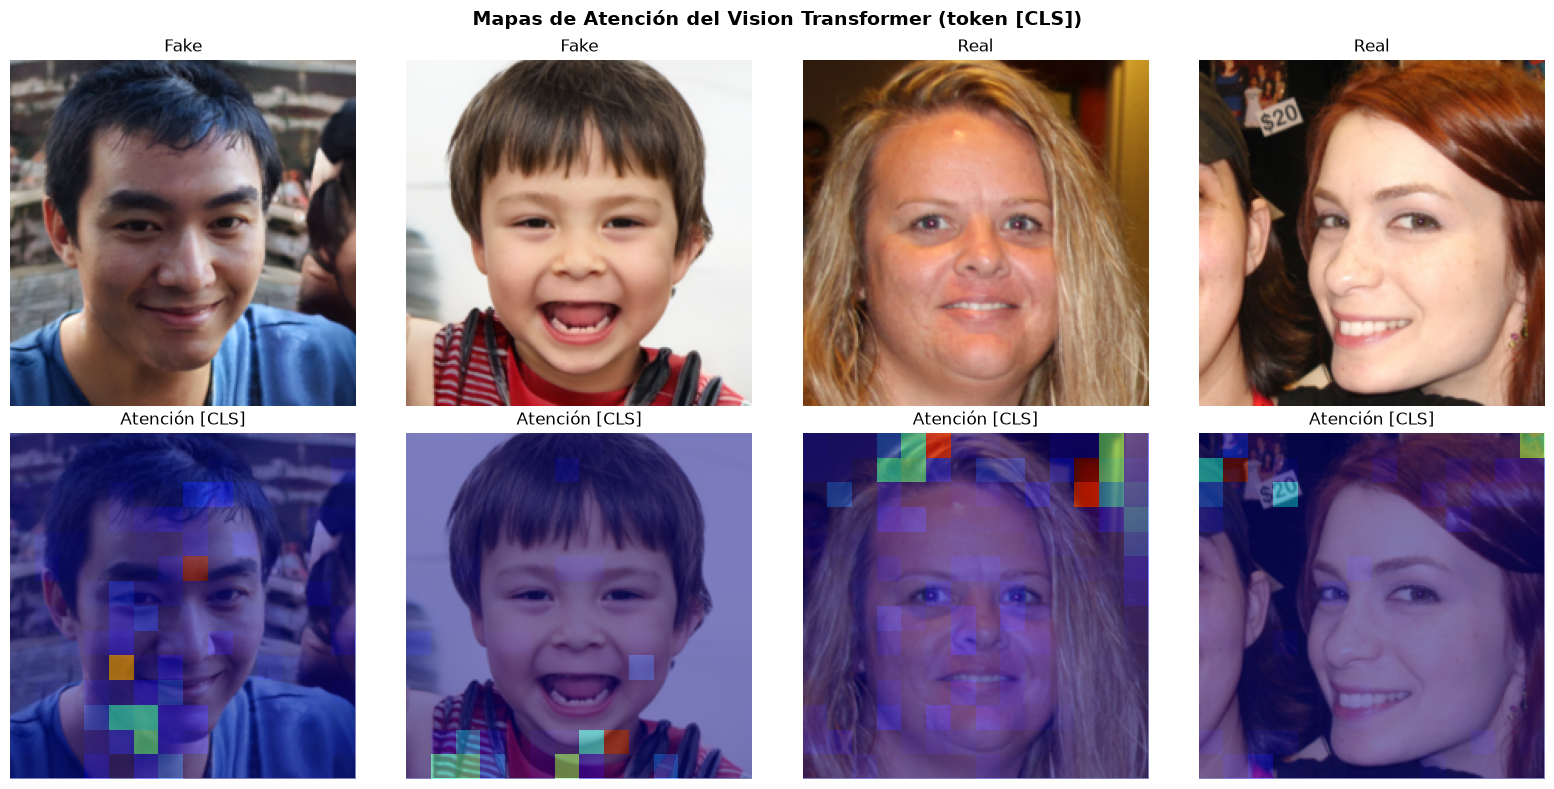

Guardado: /data/ulead-04/proyecto_paralela/figures/attention_maps.png


In [7]:
# Visualizar mapas de atención sobre 4 ejemplos del test set (2 real, 2 fake)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

sample_indices = []
labels_seen = {0: 0, 1: 0}
i = 0
while len(sample_indices) < 4 and i < len(test_ds):
    _, lbl = test_ds[i]
    lbl = int(lbl)
    if labels_seen[lbl] < 2:
        sample_indices.append(i)
        labels_seen[lbl] += 1
    i += 1

for col, idx in enumerate(sample_indices):
    img_tensor, label = test_ds[idx]
    label_name = "Real" if label == 1 else "Fake"

    attn_map = get_cls_attention_map(model, img_tensor, device)

    # Imagen original (denormalizada para mostrar)
    img_np = img_tensor.cpu().numpy()
    img_denorm = (img_np.transpose(1, 2, 0) * IMAGENET_STD) + IMAGENET_MEAN
    img_denorm = np.clip(img_denorm, 0, 1)

    axes[0, col].imshow(img_denorm)
    axes[0, col].set_title(f"{label_name}")
    axes[0, col].axis("off")

    axes[1, col].imshow(img_denorm)
    axes[1, col].imshow(attn_map, cmap="jet", alpha=0.5, extent=(0, IMG_SIZE, IMG_SIZE, 0))
    axes[1, col].set_title("Atención [CLS]")
    axes[1, col].axis("off")

plt.suptitle("Mapas de Atención del Vision Transformer (token [CLS])", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "attention_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {FIGURES_DIR / 'attention_maps.png'}")


## 6. Clasificar tu propia foto

Sube una foto tuya (o de cualquier persona) a la carpeta `data/uploads/` del
proyecto en Kabré (vía OnDemand → Files → Upload), y cambia la variable
`MY_PHOTO_PATH` abajo con el nombre del archivo.

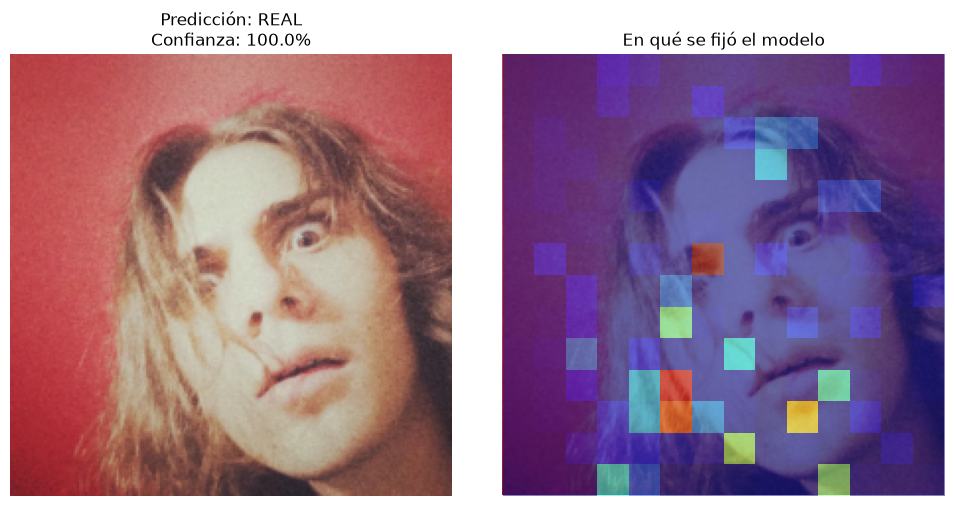


  Predicción:     REAL
  P(Real):        0.9999
  P(Fake):        0.0001
  Confianza:      100.0%


In [8]:
UPLOADS_DIR = PROJECT_ROOT / "data" / "uploads"
UPLOADS_DIR.mkdir(parents=True, exist_ok=True)

def classify_photo(image_path, model, device, show=True):
    """
    Clasifica una foto arbitraria (cualquier tamaño/formato) como
    real o generada por StyleGAN3, aplicando el mismo preprocesamiento
    que se usó para entrenar el modelo.
    """
    image_path = Path(image_path)
    assert image_path.exists(), f"No se encontró la imagen: {image_path}"

    # Preprocesamiento idéntico al del pipeline de entrenamiento
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

    arr = np.asarray(img_resized, dtype=np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    arr = arr.transpose(2, 0, 1)
    tensor = torch.from_numpy(np.ascontiguousarray(arr, dtype=np.float32))

    model.eval()
    with torch.no_grad():
        logits = model(tensor.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pred_label = "REAL" if probs[1] > probs[0] else "FAKE (generado por IA)"
    confidence = max(probs)

    attn_map = get_cls_attention_map(model, tensor, device)

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_resized)
        axes[0].set_title(f"Predicción: {pred_label}\nConfianza: {confidence:.1%}")
        axes[0].axis("off")

        axes[1].imshow(img_resized)
        axes[1].imshow(attn_map, cmap="jet", alpha=0.5, extent=(0, IMG_SIZE, IMG_SIZE, 0))
        axes[1].set_title("En qué se fijó el modelo")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    print(f"\n{'='*50}")
    print(f"  Predicción:     {pred_label}")
    print(f"  P(Real):        {probs[1]:.4f}")
    print(f"  P(Fake):        {probs[0]:.4f}")
    print(f"  Confianza:      {confidence:.1%}")
    print(f"{'='*50}")

    return {"prediction": pred_label, "p_real": float(probs[1]), "p_fake": float(probs[0])}


# ── Cambia esta ruta por tu foto subida ────────────────────────────────────
MY_PHOTO_PATH = UPLOADS_DIR / "mi_foto.jpg"

if MY_PHOTO_PATH.exists():
    result = classify_photo(MY_PHOTO_PATH, model, device)
else:
    print(f"⚠️  Sube una foto a: {UPLOADS_DIR}")
    print(f"    Luego cambia MY_PHOTO_PATH y vuelve a correr esta celda.")


## 7. Exportar Resumen para el Dashboard (Etapa 6)

In [9]:
summary = {
    "model": "ViT-B/16 (torchvision, ImageNet preentrenado, fine-tuned completo)",
    "device": str(device),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "best_epoch": checkpoint["epoch"] + 1,
    "best_val_auc": float(checkpoint["best_auc"]),
    "test_metrics": test_metrics,
    "n_test_samples": len(test_ds),
    "n_train_samples": 16000,
    "n_val_samples": 2000,
    "avg_train_throughput_img_s": float(df_log["train_throughput_img_s"].mean()),
    "total_training_time_s": float(df_log["train_time_s"].sum() + df_log["val_time_s"].sum()),
}

with open(RESULTS_DIR / "evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print(f"\n✅ Guardado en {RESULTS_DIR / 'evaluation_summary.json'}")


{
  "model": "ViT-B/16 (torchvision, ImageNet preentrenado, fine-tuned completo)",
  "device": "cuda",
  "gpu": "NVIDIA L40S",
  "best_epoch": 11,
  "best_val_auc": 0.9519655,
  "test_metrics": {
    "accuracy": 0.87,
    "precision": 0.8375912408759124,
    "recall": 0.918,
    "f1": 0.8759541984732825,
    "auc_roc": 0.943761
  },
  "n_test_samples": 2000,
  "n_train_samples": 16000,
  "n_val_samples": 2000,
  "avg_train_throughput_img_s": 565.0886666666668,
  "total_training_time_s": 452.20000000000005
}

✅ Guardado en /data/ulead-04/proyecto_paralela/results/evaluation_summary.json


## 8. Commit de resultados

```bash
cd /data/ulead-04/proyecto_paralela
git add figures/ results/evaluation_summary.json notebooks/
git commit -m "feat: evaluación del ViT - matriz de confusión, ROC, atención, clasificador de fotos"
```
